In [1]:
import utils

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import re
import os
import seaborn as sns # Loads in the theme

plt.rcParams.update(plt.rcParamsDefault)
pd.set_option('display.max_columns', None)

In [2]:
# Make output folder
output_dir = os.path.join('..','plots','fMRI','volume_based')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Preparation
pilot_analysis = False
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers based on whether we're analysing the study or pilot data
if pilot_analysis:
    raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
    unique_subject_ids = [802,803,804,805,806,808,809,811,813,814,815]
    unique_sessions = [1]
else:
    raw_output_path = '/Volumes/project/3025011.02/raw/'
    unique_subject_ids = [52, 53, 54, 55, 57]
    unique_sessions = [2, 3, 4]

# Load and combine the datasets
combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, pilot_analysis, binary_output=False)

     subject_id     session  previous_outcome subjectively_correct  stay
0       sub-052  session-02              <NA>                 Late  <NA>
1       sub-052  session-02              <NA>                False  <NA>
2       sub-052  session-02              <NA>                 True  <NA>
3       sub-052  session-02              <NA>                 True  <NA>
4       sub-052  session-02              <NA>                False     1
...         ...         ...               ...                  ...   ...
6775    sub-057  session-04              <NA>                 True  <NA>
6776    sub-057  session-04                 1                 True     1
6777    sub-057  session-04                 1                 True     1
6778    sub-057  session-04                 1                 True     1
6779    sub-057  session-04                 1                False  <NA>

[6780 rows x 5 columns]


In [4]:
# Combine with ROI-based data
fsl_output_folder = '/Volumes/project/3025011.02/bids/derivatives/fsl'

def session_to_bids_format(session_label):
    """'session-02' -> 'ses-mri02'"""
    m = re.match(r'session-(\d+)', str(session_label))
    return f'ses-mri{m.group(1)}' if m else None


def load_roi_stats_for_subject_session(sub, ses_bids, fsl_root):
    """
    Find all copeN_roi_stats.csv files in every .feat folder for a given
    (subject, session). Flatten to a dict of column_name -> value, where the
    feat-folder suffix is included in the key so stats from different feat
    variants don't overwrite each other.
    """
    func_dir = Path(fsl_root) / sub / ses_bids / 'func'
    if not func_dir.is_dir():
        return {}

    # Every .feat folder for this subject-session, second-level dirs excluded.
    # Naming convention from e_feat_first_level.sh:
    #   {sub}_{ses}.feat                 -> suffix ''
    #   {sub}_{ses}_{suffix}.feat        -> suffix '{suffix}'
    prefix = f'{sub}_{ses_bids}'
    csv_pattern = re.compile(r'^cope(\d+)_roi_stats\.csv$')

    flat = {}
    for featdir in sorted(func_dir.glob(f'{prefix}*.feat')):
        base = featdir.name[:-len('.feat')]           # drop .feat
        rest = base[len(prefix):]                     # '' or '_a_comp_cor'
        feat_suffix = rest.lstrip('_')                # '' or 'a_comp_cor'

        stats_dir = featdir / 'stats'
        if not stats_dir.is_dir():
            continue

        for csv_path in sorted(stats_dir.iterdir()):
            m = csv_pattern.match(csv_path.name)
            if not m:
                continue
            cope_n = int(m.group(1))

            df = pd.read_csv(csv_path, sep=';')
            stat_cols = [c for c in df.columns if c != 'mask']
            for _, row in df.iterrows():
                mask = row['mask']
                for stat in stat_cols:
                    # Include feat_suffix in the column name so different feat
                    # variants produce distinct columns. Empty suffix -> no
                    # leading component.
                    parts = [p for p in (feat_suffix, f'cope{cope_n}', mask, stat) if p]
                    col = '_'.join(parts)
                    flat[col] = row[stat]

    return flat


def add_roi_stats_to_combined(combined_df, fsl_root):
    cache = {}
    pairs = combined_df[['subject_id', 'session']].drop_duplicates()
    for _, r in pairs.iterrows():
        sub, ses = r['subject_id'], r['session']
        ses_bids = session_to_bids_format(ses)
        cache[(sub, ses)] = (
            load_roi_stats_for_subject_session(sub, ses_bids, fsl_root)
            if ses_bids else {}
        )

    stats_rows = [
        cache[(r.subject_id, r.session)]
        for r in combined_df.itertuples(index=False)
    ]
    stats_df = pd.DataFrame(stats_rows, index=combined_df.index)

    missing = [k for k, v in cache.items() if not v]
    if missing:
        print(f'No ROI stats found for {len(missing)} subject-session pair(s):')
        for sub, ses in missing:
            print(f'  {sub} {ses}')

    return pd.concat([combined_df, stats_df], axis=1)

In [5]:
# --- Run it ---
combined_results_dataframe = add_roi_stats_to_combined(
    combined_results_dataframe, fsl_output_folder
)

In [6]:
print(combined_results_dataframe)

      trial  emotional_cue_time  response objectively_correct  \
0         8        1.769530e+09  approach               False   
1         9        1.769530e+09  approach               False   
0        10        1.769530e+09  approach                True   
1        11        1.769530e+09  approach                True   
2        12        1.769530e+09     avoid                True   
...     ...                 ...       ...                 ...   
3327    447        1.772556e+09     avoid                True   
3328    448        1.772556e+09     avoid                True   
3328    449        1.772556e+09  approach                True   
3329    450        1.772556e+09  approach                True   
3329    451        1.772556e+09  approach               False   

     subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                   False   1.769530e+09  0.482   1.769530e+09             2   
1                   False   1.769530e+09  0.553   1.769530e

  subject_id  a_comp_cor_cope5_harvard_oxford_amygdala_L_zstat_mean_amygdala  \
0    sub-052                                          -0.049598                
1    sub-053                                           0.360156                
2    sub-054                                           0.571366                
3    sub-055                                          -0.327669                
4    sub-057                                          -0.459575                

   a_comp_cor_cope5_harvard_oxford_amygdala_L_zstat_mean_sham  \
0                                           0.430071            
1                                           0.744144            
2                                          -0.017410            
3                                           0.080098            
4                                           1.602278            

   a_comp_cor_cope5_harvard_oxford_amygdala_R_zstat_mean_amygdala  \
0                                           0.511241       

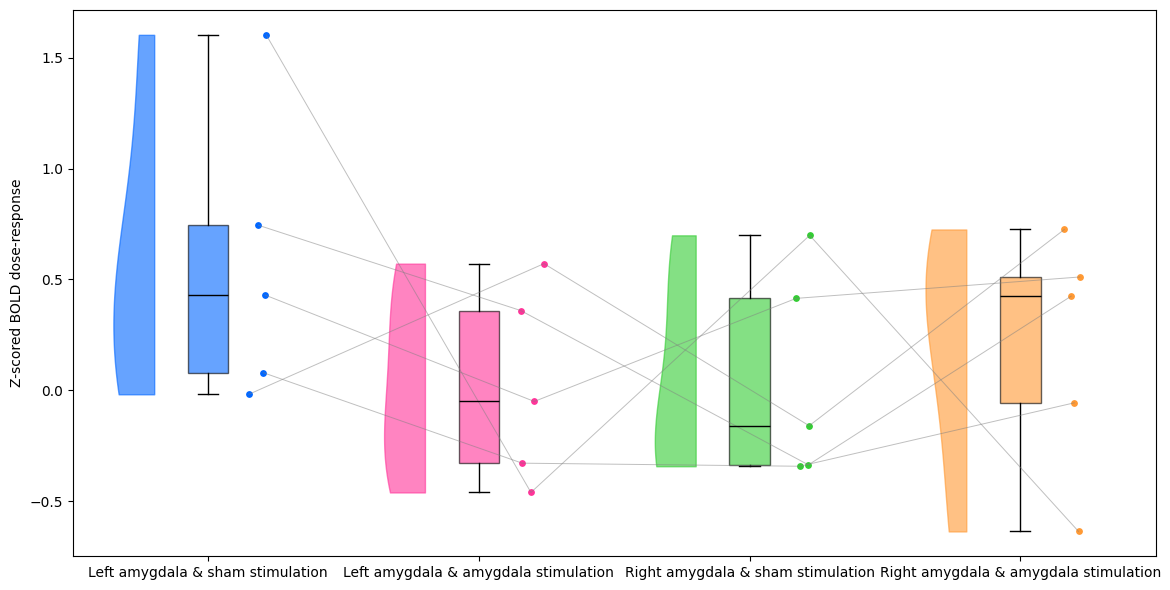

In [7]:
combined_results_pivoted = (
    combined_results_dataframe
    .groupby(['subject_id','stimulation_condition'])[['a_comp_cor_cope5_harvard_oxford_amygdala_L_zstat_mean', 'a_comp_cor_cope5_harvard_oxford_amygdala_R_zstat_mean']]
    .mean()
    .reset_index()
)

combined_results_pivoted = combined_results_pivoted[combined_results_pivoted['stimulation_condition']!='dacc']

combined_results_wide = (
    combined_results_pivoted
    .pivot(
        index=['subject_id'],   # whatever identifies a row
        columns='stimulation_condition',                # the column with the two strings
        values=['a_comp_cor_cope5_harvard_oxford_amygdala_L_zstat_mean', 'a_comp_cor_cope5_harvard_oxford_amygdala_R_zstat_mean']
    )
)
combined_results_wide.columns = [f"{val}_{cond}" for val, cond in combined_results_wide.columns]
combined_results_wide = combined_results_wide.reset_index()
print(combined_results_wide)

# Plot the four groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    combined_results_wide,
    columns=['a_comp_cor_cope5_harvard_oxford_amygdala_L_zstat_mean_sham','a_comp_cor_cope5_harvard_oxford_amygdala_L_zstat_mean_amygdala','a_comp_cor_cope5_harvard_oxford_amygdala_R_zstat_mean_sham','a_comp_cor_cope5_harvard_oxford_amygdala_R_zstat_mean_amygdala'],
    labels=['Left amygdala & sham stimulation','Left amygdala & amygdala stimulation','Right amygdala & sham stimulation','Right amygdala & amygdala stimulation'],
    output_dir=output_dir,
    ylabel_name='Z-scored BOLD dose-response',
    plot_name='z-statistic_test'
)